<a href="https://colab.research.google.com/github/Malaika944/feature_engineering/blob/main/Embedded_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

In [25]:
df = pd.read_csv('/content/insurance_data.csv',index_col=0)[['PatientID','age','bloodpressure','bmi','children','claim']] #to remove pandas indexing

df.dropna()

,PatientID,age,bloodpressure,bmi,children,claim
index,,,,,,
0,1,39.0,91,23.2,0,1121.87
1,2,24.0,87,30.1,0,1131.51
7,8,19.0,100,41.1,0,1146.80
8,9,20.0,86,43.0,0,1149.40
9,10,30.0,97,53.1,0,1163.46
...,...,...,...,...,...,...
1335,1336,44.0,88,35.5,0,55135.40
1336,1337,59.0,120,38.1,1,58571.07
1337,1338,30.0,91,34.5,3,60021.40


In [40]:
#To check and drop null values
df.isnull().sum()
df=df.dropna()

In [26]:
from sklearn.model_selection import train_test_split

In [41]:
#SPlit the data in output and input
x=df.iloc[:,0:-1]
y= df.iloc[:,-1]

In [42]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)

In [43]:
x_train.head()

,PatientID,age,bloodpressure,bmi,children
index,,,,,
1287,1288,32.0,96,39.0,0
1116,1117,42.0,106,25.6,2
971,972,56.0,89,21.7,0
603,604,39.0,91,19.6,1
175,176,59.0,81,39.8,0


In [38]:
#import model
from sklearn.linear_model import Lasso
lasso=Lasso(alpha=0.01)

In [44]:
lasso.fit(x_train,y_train)

Lasso(alpha=0.01)

In [45]:
#check important features
lasso.coef_

array([  24.88543711,  -19.57064408,  171.35305977,  143.28463133,
       -178.72865982])

In [46]:
cols=x_train.columns

<Axes: >

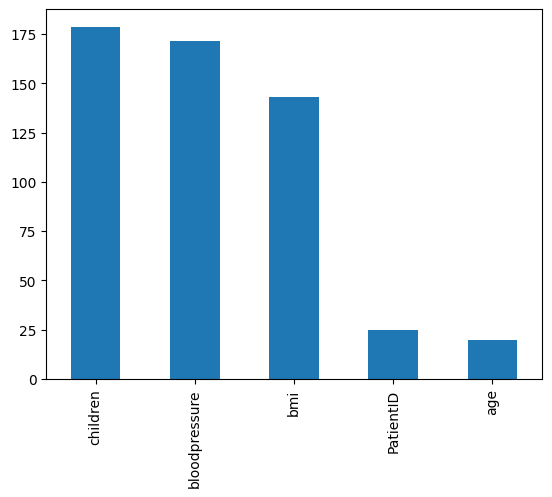

In [47]:
#Visualize results
import matplotlib.pyplot as plt
import numpy as np

pd.Series(np.abs(lasso.coef_),index=cols).sort_values(ascending=False).plot(kind='bar')

Select from Model(Scikit learn transformer for feature selection)

In [59]:
df = pd.read_csv('/content/insurance_data.csv')[['PatientID','age','bloodpressure','bmi','children','claim']]
df

,PatientID,age,bloodpressure,bmi,children,claim
0,1,39.0,91,23.2,0,1121.87
1,2,24.0,87,30.1,0,1131.51
2,3,NaN,82,33.3,0,1135.94
3,4,NaN,80,33.7,0,1136.40
4,5,NaN,100,34.1,0,1137.01
...,...,...,...,...,...,...
1335,1336,44.0,88,35.5,0,55135.40
1336,1337,59.0,120,38.1,1,58571.07
1337,1338,30.0,91,34.5,3,60021.40
1338,1339,37.0,106,30.4,0,62592.87


In [60]:
x_train,x_test,y_train,y_test = train_test_split(df.iloc[:,0:-1],df.iloc[:,-1],random_state=42,test_size=0.2)

In [66]:
from sklearn.tree import DecisionTreeRegressor
model =DecisionTreeRegressor()

In [67]:
from sklearn.feature_selection import SelectFromModel

In [71]:
sfm = SelectFromModel(model,threshold =0.1)

In [72]:
sfm.fit(x_train,y_train)

SelectFromModel(estimator=DecisionTreeRegressor(), threshold=0.1)

In [73]:
sfm.get_support(indices=True)

array([0])

In [78]:
sfm.feature_names_in_[sfm.get_support(indices=True)]

array(['PatientID'], dtype=object)